# Graphipy Tutorial

In this tutorial you will learn the main functionalities of the `Graphipy` class. `Graphipy` can be used whenever the data for which magnitude should be computed has a graph structure. Magnitude can be computed on the graph structure only or also taking node features into account.

## Outline Tutorial

1. Introduction
    1. when to use graphipy
2. Importing packages 
    import different graphs here?
3. Computing examples
    1. graph structure
    2. full (maybe with remark to just features?)
    3. change distance
4. Magnitude Differences

## Importing Packages

Before we begin, we must import the required packages. Please ensure that you have activated your virtual environment and installed the dependencies using poetry before this step (see **Dependencies** in the README).

In [1]:
# import statements for external packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import networkx as nx
import random

# import statements from magnipy repo
from magnipy.graphipy import Graphipy
from magnipy.utils.tutorial_data import (
    plot_graphs,
    plot_mag_funs,
    plot_dist_matrices,
)

## Computing Magnitude

The `Graphipy` class uses `NetworkX` for its graph objects. Hence, let's initialize some `NetworkX` graphs we will use throughout the tutorial.

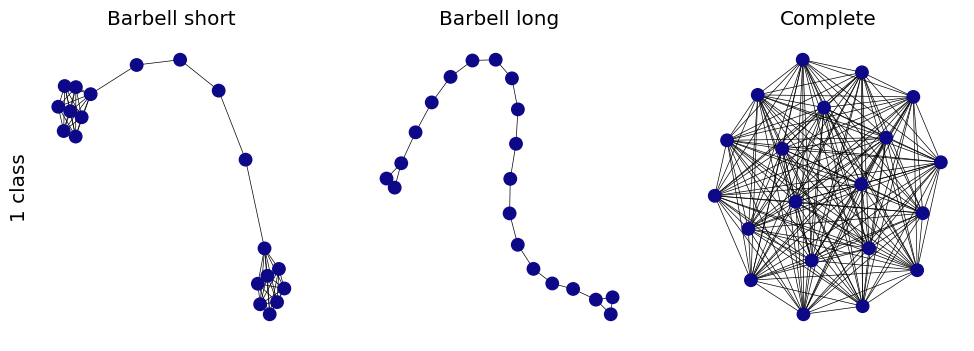

In [2]:
# initializing graphs
barbell_short = nx.barbell_graph(8, 4)
barbell_long = nx.barbell_graph(3, 14)
complete = nx.complete_graph(20)

graphs = [barbell_short, barbell_long, complete]
graphnames = ["Barbell short", "Barbell long", "Complete"]

# plotting the graphs
plot_graphs(
    graphs=graphs,
    features=None,
    positions=[nx.spring_layout(G) for G in graphs],
    graphnames=graphnames,
)

### Magnitude on the Graph Structure

Let us at first only look at the graph structure, so we do not take into consideration any node features. To do this, select `mode = 'structure'` while initializing the `Graphipy` objects. The magnitude computation is based on some distance between the nodes, there are different options implemented as demonstrated below.

In [11]:
# different distances for graphs found in `Graphipy`
metrics = [
    "shortest_path_distance",
    "diffusion_distance",
    "resistance_distance",
    "heat_kernel_distance",
]

graphis_structure = {metric: [] for metric in metrics}
magnis_structure = {metric: [] for metric in metrics}

# specifying the scales we want to compute the magnitude on
ts = np.linspace(0, 10, 100)

# initialize Graphipy objects for every metric and graph and compute the magnitude
for metric in metrics:
    for i, graph in enumerate(graphs):
        graphi = Graphipy(G=graph, mode="structure", metric=metric, ts=ts)
        magni, _ = graphi.get_magnitude()

        graphis_structure[metric].append(graphi)
        magnis_structure[metric].append(magni)

Let's plot the different magnitude functions. Note that for each distance the complete graph is the least diverse and the barbell graph with the longer handle is the most diverse. This is what we would expect from a diversity measure.

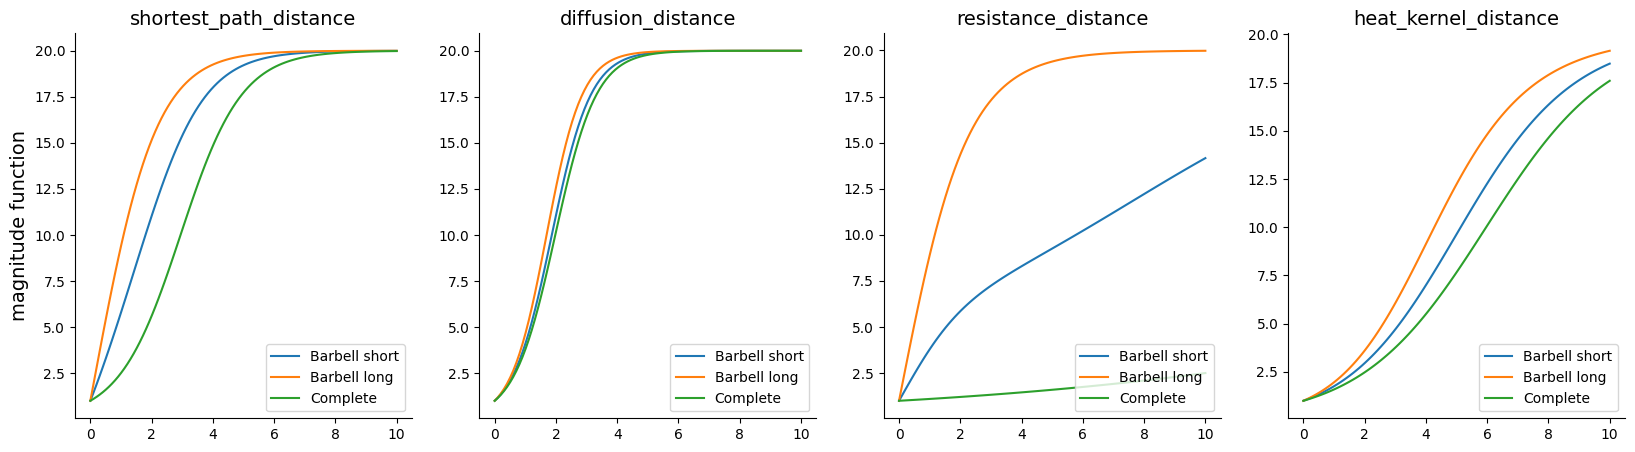

In [12]:
plot_mag_funs(
    cols=metrics, graphnames=graphnames, magnis=magnis_structure, ts=ts
)

We can also visualize the corresponding distance matrices of the graph nodes based on which the magnitude gets computed.

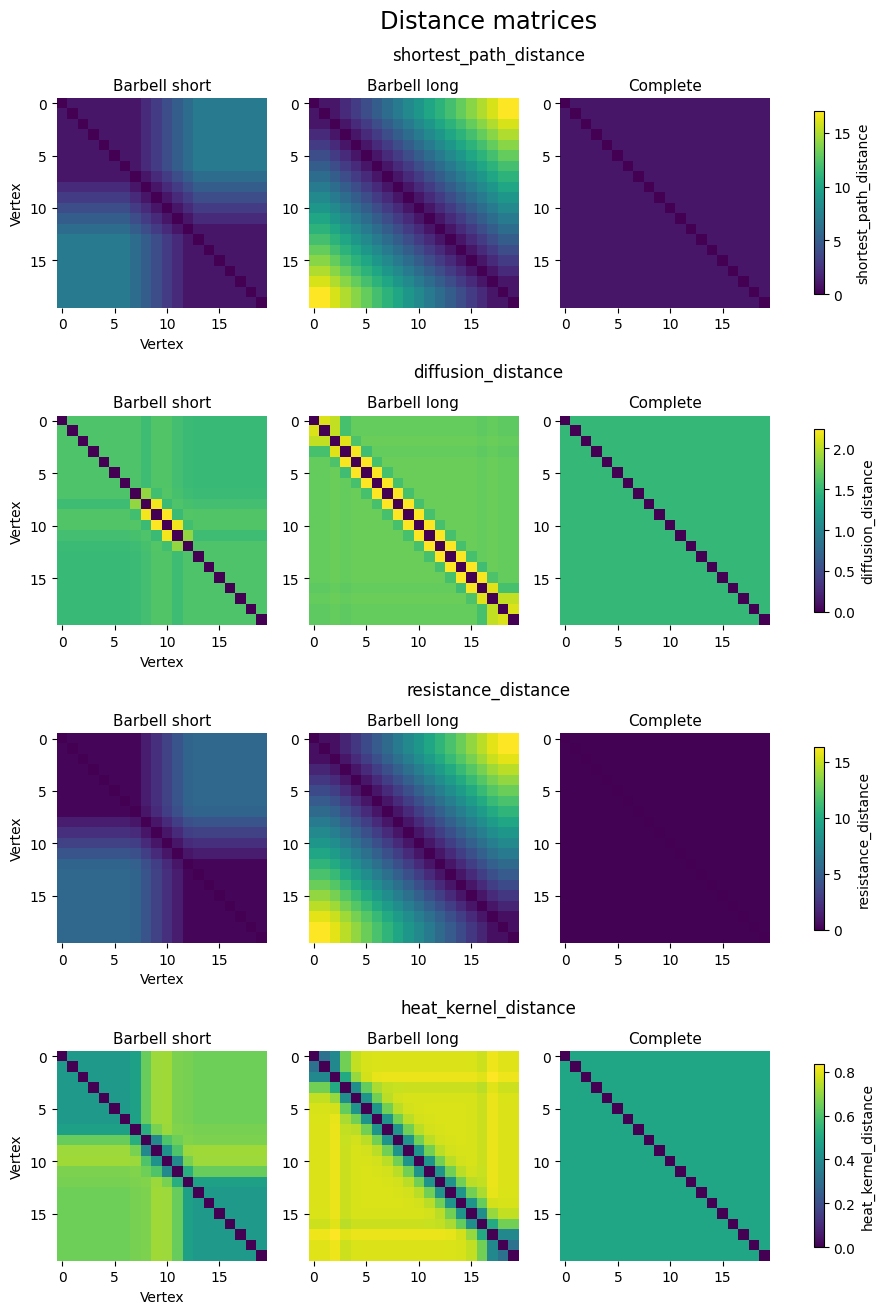

In [5]:
plot_dist_matrices(
    graphis=graphis_structure,
    graphnames=graphnames,
    rows=metrics,
    metrics=metrics,
)

### Magnitude using Features and Graph Structure

If we have an attributed graph, we can take the node features into account for computing the magnitude.
Using `mode=full` we compute the magnitude based on the graph structure *and* the features. To be precise, we compute distances between the features based on a metric we specify when initializing the `Graphipy` object and use these distances as weights to our graph. The feature distances one can choose from can be found in `distances.py`. The similarity matrix for the magnitude computation is then based on the distances obtained by computing the geodesic distance between the nodes of the weighted graph. 

Let us initialize some features and plot the graphs with the features.

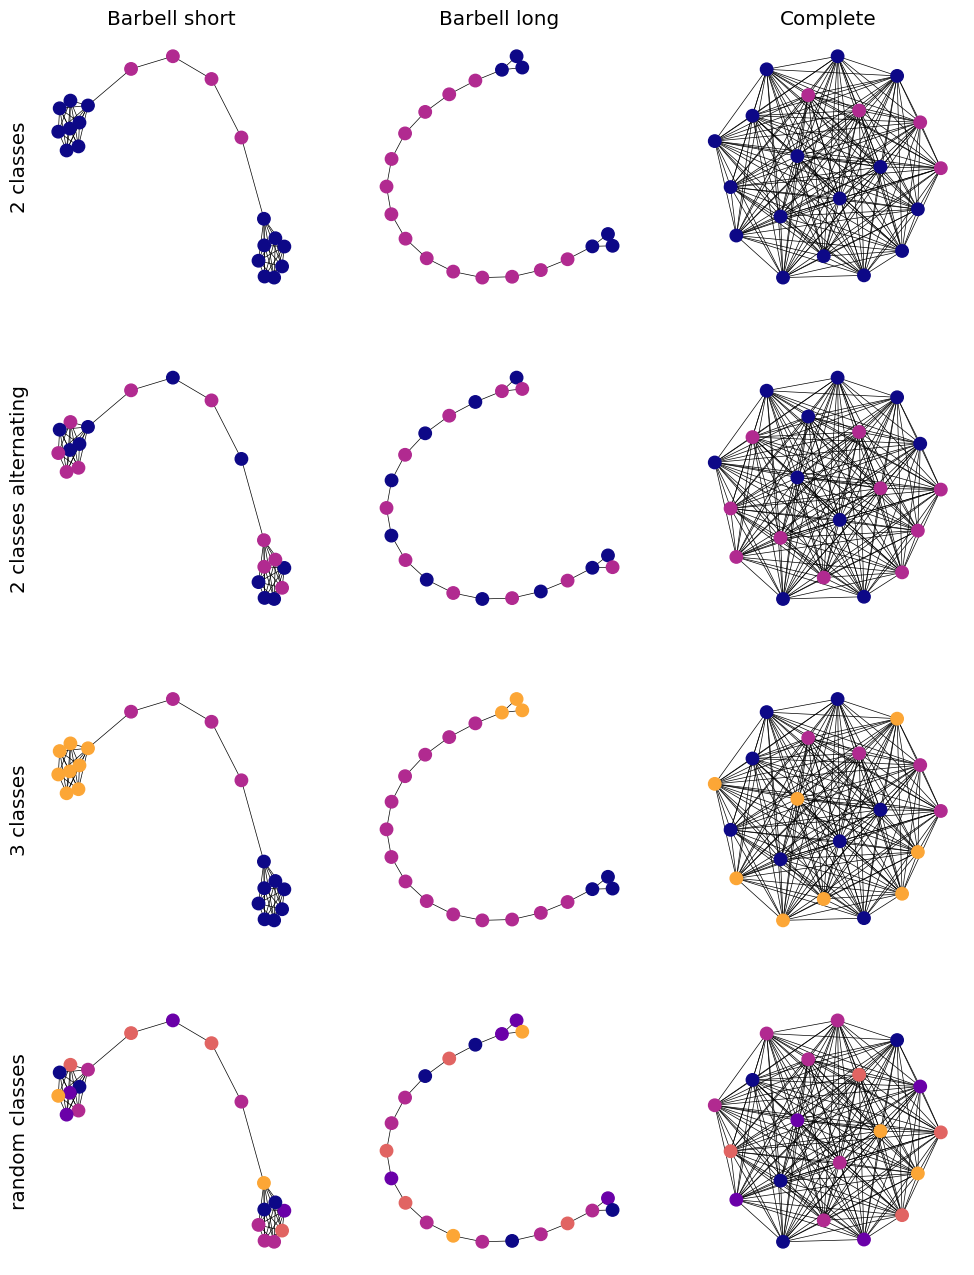

In [6]:
# initializing features, need to be 2D arrays
X_1class = np.reshape(np.array([0] * 20), (-1, 1))
X_2classes_short = np.reshape(np.array([0] * 8 + [2] * 4 + [0] * 8), (-1, 1))
X_2classes_long = np.reshape(np.array([0] * 3 + [2] * 14 + [0] * 3), (-1, 1))
X_2classes_alternating = np.reshape(np.array([0, 2] * 10), (-1, 1))
X_3classes_short = np.reshape(np.array([0] * 8 + [2] * 4 + [4] * 8), (-1, 1))
X_3classes_long = np.reshape(np.array([0] * 3 + [2] * 14 + [4] * 3), (-1, 1))
X_random = np.reshape(
    np.array(np.random.choice(range(5), size=20, replace=True)), (-1, 1)
)

features = [
    [X_2classes_short, X_2classes_long, X_2classes_short],
    [X_2classes_alternating] * 3,
    [X_3classes_short, X_3classes_long, X_3classes_short],
    [X_random] * 3,
]
featurenames = [
    "2 classes",
    "2 classes alternating",
    "3 classes",
    "random classes",
]

# plotting the graphs with features
plot_graphs(
    graphs=graphs,
    positions=[nx.spring_layout(G) for G in graphs],
    graphnames=graphnames,
    features=features,
    featurenames=featurenames,
)

The first way to pass the features is simply by specifying a feature matrix $X$, where each row corresponds to a node feature, when initializing our `graphipy` object. Let's do this for the first two feature matrices we have as seen in the plot above.

c:\Users\haeuserm\Programming Projects\magnipy\magnipy\graphipy.py:150: UserWarning: "The graph already has features assigned to its nodes. Overriding the features with the input X."
  warnings.warn(


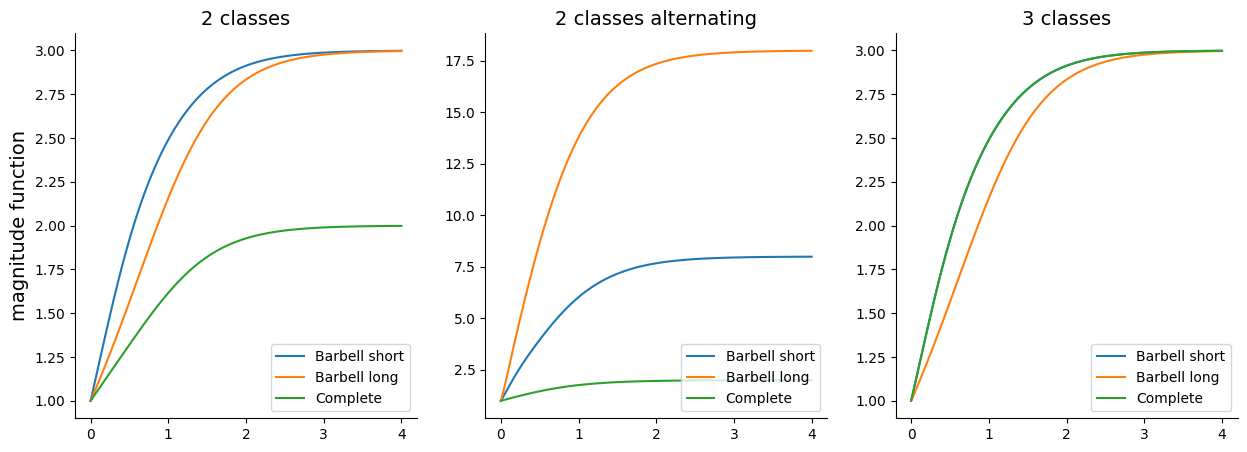

In [17]:
graphis_full = {feature: [] for feature in featurenames}
magnis_full = {feature: [] for feature in featurenames}

# initializing graphipy objects and specifying the features by passing X
ts = np.linspace(0, 4, 100)

for i, feature in enumerate(featurenames[0:-1]):
    for j, graph in enumerate(graphs):
        graphi = Graphipy(
            X=features[i][j],
            G=graph,
            ts=ts,
            mode="full",
            metric="euclidean",
            method="spread",
        )
        magni, _ = graphi.get_magnitude()
        graphis_full[feature].append(graphi)
        magnis_full[feature].append(magni)

# plotting the magnitude functions
plot_mag_funs(
    cols=featurenames[0:-1], graphnames=graphnames, magnis=magnis_full, ts=ts
)

The other way to pass the features is to initialize the `Graphipy` object with an attributed graph. We show this method for the last type of features we have, which are random features drawn from $\{0, \dots, 4\}$ with replacement.

In [18]:
for j, graph in enumerate(graphs):
    # set node features in a copy of the graph
    copy = graph.copy()
    nx.set_node_attributes(
        G=copy,
        values={i: X_random[i] for i in range(X_random.shape[0])},
        name="feature",
    )
    # initialize Graphipy object with attributed graph instead of specifying the feature matrix X
    graphi = Graphipy(
        G=copy,
        ts=ts,
        mode="full",
        metric="euclidean",
        method="spread",
    )
    magni, _ = graphi.get_magnitude()
    graphis_full["random classes"].append(graphi)
    magnis_full["random classes"].append(magni)

Let's plot all the magnitude functions computed with features and the graph structure. Note how the feature  impact the magnitude functions. One thing to point out that the megnitude function no longer necesssarily converges to the number of nodes in the graph. This is due to the fact that the feature distance for nodes from the same class is $0$, so they collapse to one point. Another thing to mention is that we no longer have the same order of diversity between the three graphs for each type of features.

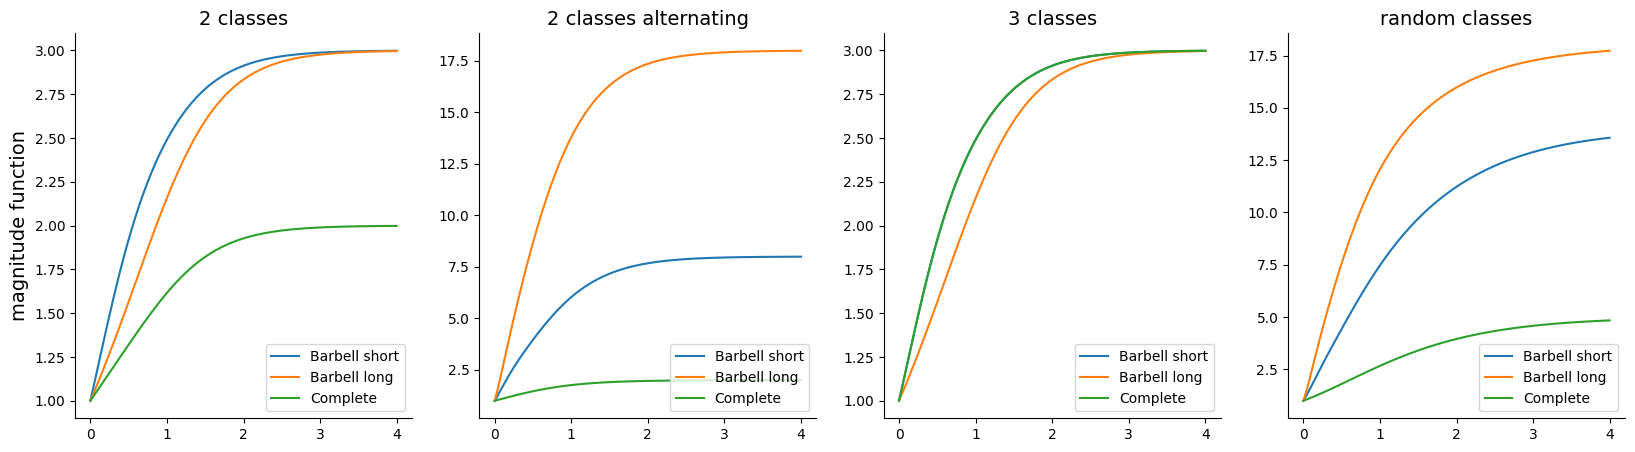

In [19]:
plot_mag_funs(
    cols=featurenames, graphnames=graphnames, magnis=magnis_full, ts=ts
)

Let us also plot the distance matrices, as mentioned above these are distances between the nodes in a weighted graph, where the weights are the distances between the features. Note that e.g. for '$2$ classes' the matrices do not have full rank, which is why we chose to use spread for the computation instead of magnitude.

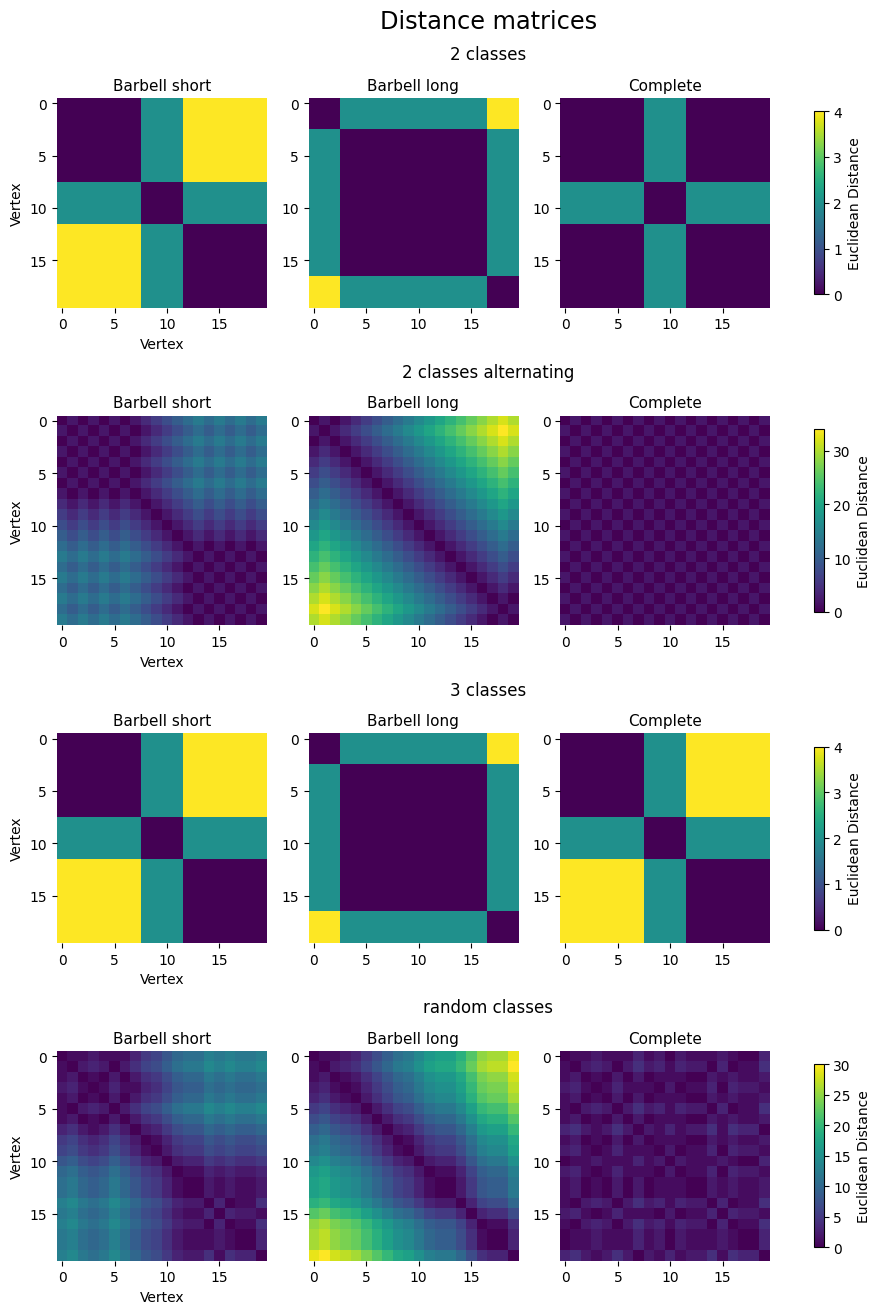

In [21]:
plot_dist_matrices(
    graphis_full,
    graphnames,
    featurenames,
    ["Euclidean Distance"] * len(featurenames),
)

### Magnitude only using features

Another option is to use the mode `attributes` where we only use a distance between features for the magnitude. This will give the same result as creating a `Magnipy` object using the features as the data with the same choice of distance function. <br>
We use the '$2$ classes' as features. Note that since the graph structure does not play a role anymore, the magnitude function for 'barbell short' and 'complete' coinicide since they use the same features.

Text(0.5, 1.0, 'Magnitude functions when using only attributes')

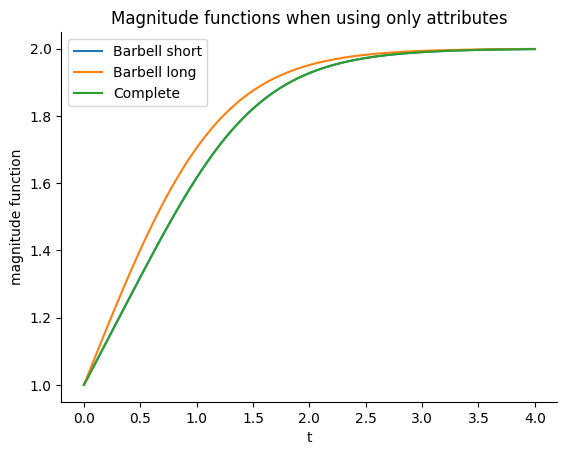

In [26]:
for j, graph in enumerate(graphs):
    # initialzing `Graphipy` objects with mode 'attributes'
    graphi_attributes = Graphipy(
        X=features[0][j],
        ts=ts,
        G=graph,
        mode="attributes",
        metric="euclidean",
        method="spread",
    )
    # plotting the magnitude functions
    graphi_attributes.plot_magnitude_function()

plt.legend([graphname for graphname in graphnames])
plt.title("Magnitude functions when using only attributes")

### Using a Custom Distance Function 

Instead of using the implemented distance functions, it is also possible to compute the magnitude using a custom distance function. Make sure that the custom distance function is compatible with the mode you are planning to use. In the example we define a distance based on the graph structure and features, so we use the mode `full`.

c:\Users\haeuserm\Programming Projects\magnipy\magnipy\graphipy.py:150: UserWarning: "The graph already has features assigned to its nodes. Overriding the features with the input X."
  warnings.warn(


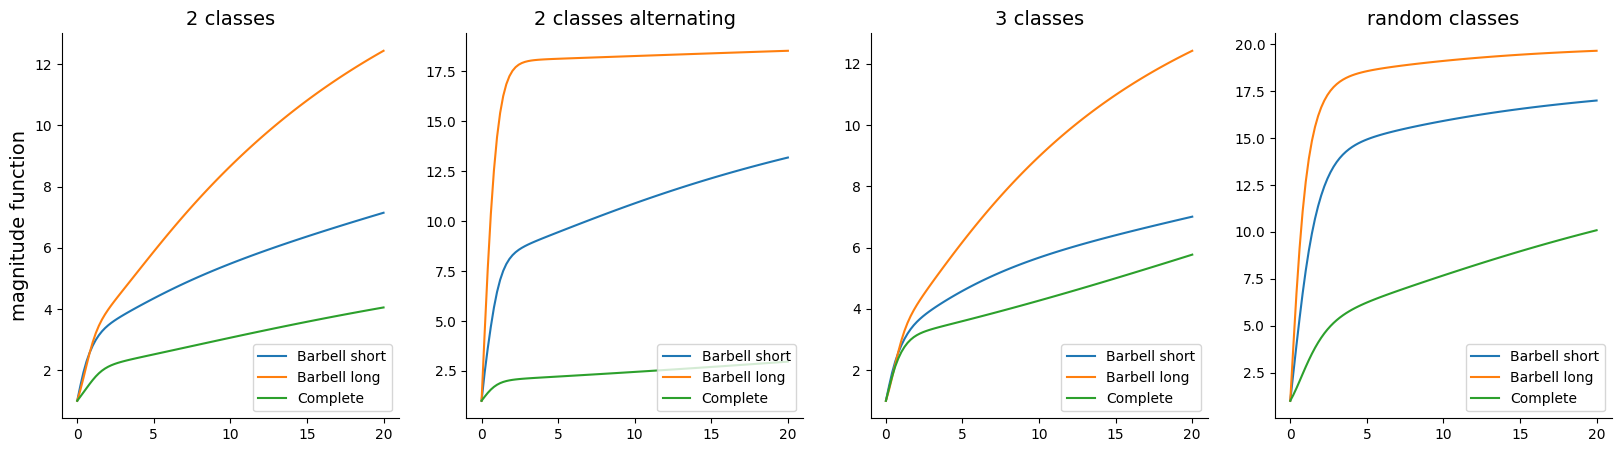

In [28]:
from scipy.sparse.csgraph import shortest_path
from magnipy.magnitude.distances import distances_scipy


# our custom distance function adds some small positive normal noise to the feature distances
def cust_dist_noise(X=None, X2=None, G=None):
    feature_dist = distances_scipy(X, X2, metric="euclidean")
    noise = np.random.normal(loc=0, scale=0.2, size=feature_dist.shape)
    noise[noise < 0] = -noise[noise < 0]
    Adj = nx.adjacency_matrix(G).todense()
    weighted_adjacency = Adj * (feature_dist + noise)
    geodesic_distances = shortest_path(weighted_adjacency, directed=False)
    return geodesic_distances


graphis_custom_noisy = {feature: [] for feature in featurenames}
magnis_custom_noisy = {feature: [] for feature in featurenames}

# initializing graphipy objects and specifying the custom distance function
ts = np.linspace(0, 20, 100)

for i, feature in enumerate(featurenames):
    for j, graph in enumerate(graphs):
        graphi = Graphipy(
            X=features[i][j],
            G=graph,
            ts=ts,
            mode="full",
            custom_dist_fn=cust_dist_noise,
            method="spread",
        )
        magni, _ = graphi.get_magnitude()
        graphis_custom_noisy[feature].append(graphi)
        magnis_custom_noisy[feature].append(magni)

# plotting
plot_mag_funs(
    cols=featurenames, graphnames=graphnames, magnis=magnis_custom_noisy, ts=ts
)

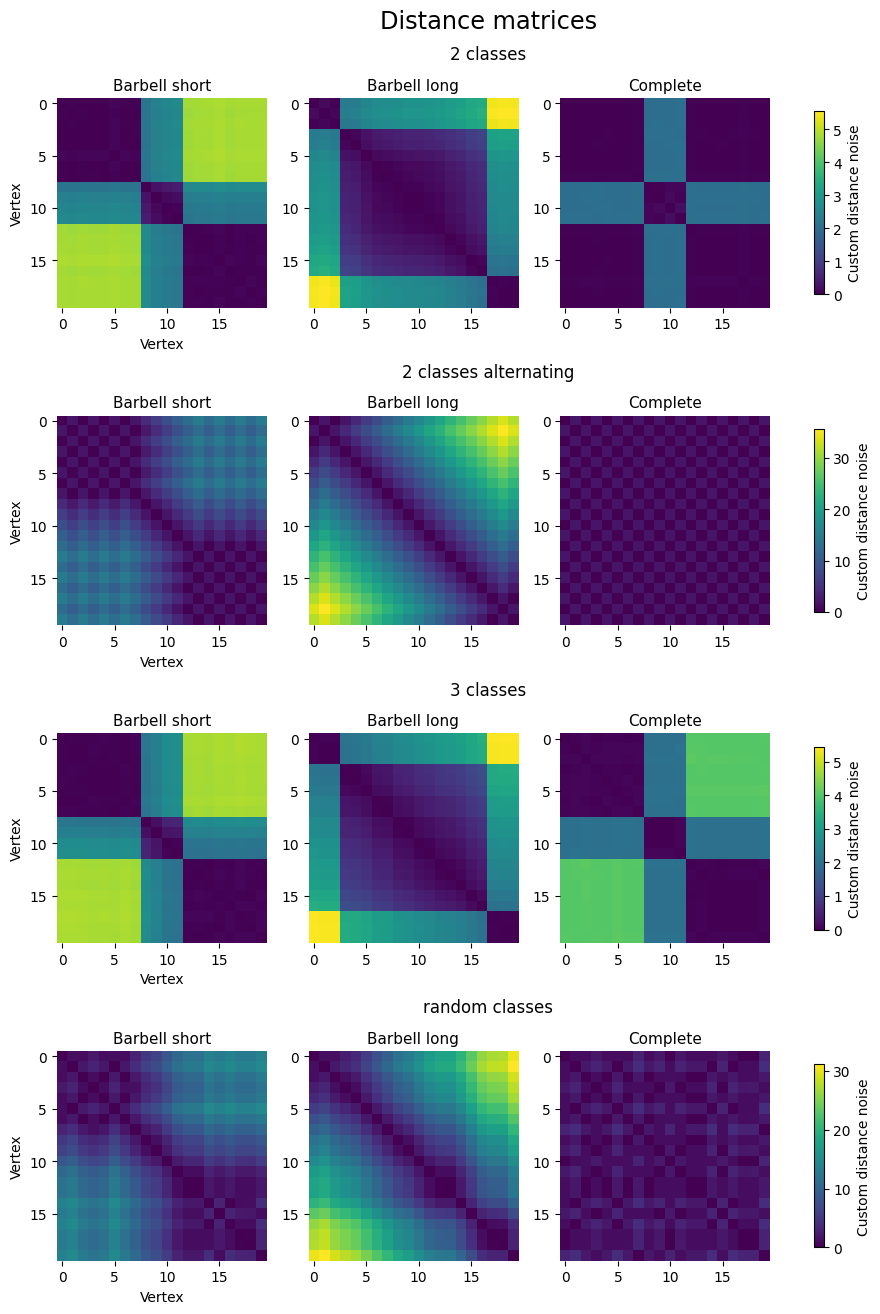

In [29]:
plot_dist_matrices(
    graphis_custom_noisy,
    graphnames,
    featurenames,
    ["Custom distance noise"] * len(featurenames),
)

## Computing Differences in Magnitude

Computing the difference in magnitude can be insightful for comparing the difference in diversity between two spaces. The `Graphipy` package includes a `_substract` method which can be used for this task. <lb>
One appplication can be found in 'Geometry-aware Edge Pooling for Graph Neural Networks' where the difference in diversity is used to decide which edge to collapse in order to find a structure preserving pooling method. <br>
The example shows the difference in magnitude for the custom distance and the magnitudes with the same features in mode `full`.

In [ ]:
diffs = {feature: [] for feature in featurenames}
diffs_ts = {feature: [] for feature in featurenames}

for feature in featurenames:
    for j in range(len(graphs)):
        # computing the differences in magnitude
        diff, diff_ts = graphis_custom_noisy[feature][j]._subtract(
            other=graphis_full[feature][j]
        )
        diffs[feature].append(diff)
        diffs_ts[feature].append(diff_ts)

Plotting the differences between the magnitude function shows that adding the noise has a large impact due to the fact that now the feature distances are not precisely $0$.

Text(0.5, 0.98, 'Differences in magnitude funtions classes with noise and without')

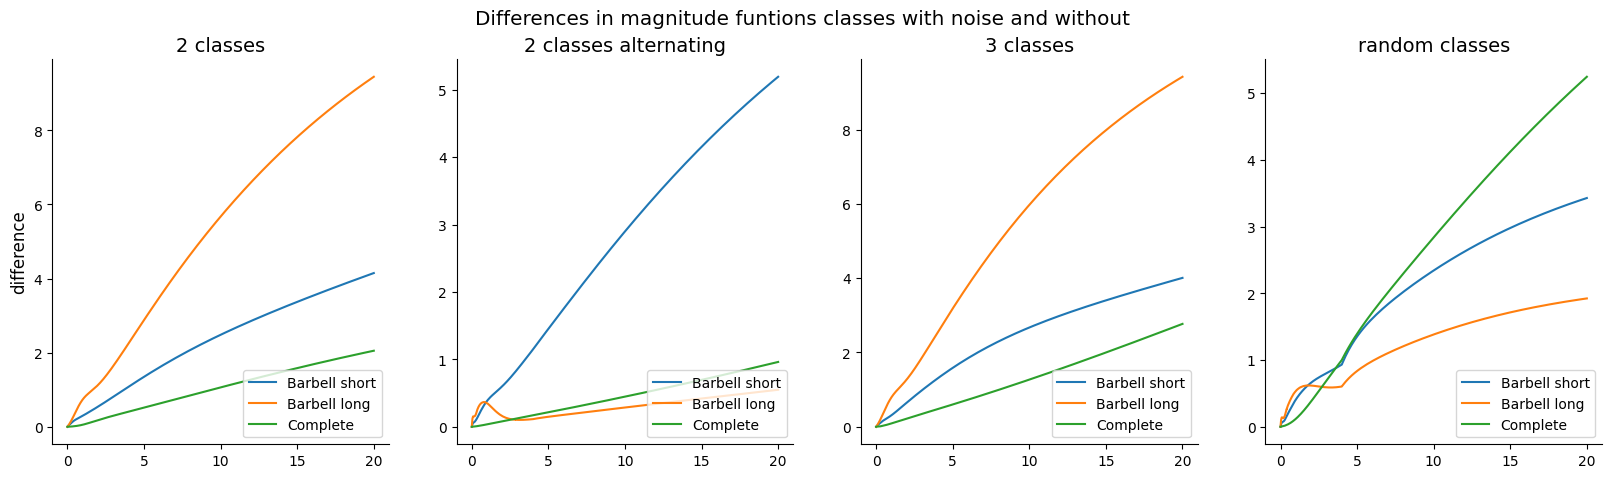

In [31]:
fig, axs = plt.subplots(1, len(featurenames), figsize=(20, 5))

for j, feature in enumerate(featurenames):
    for i, graphname in enumerate(graphnames):
        axs[j].plot(diffs_ts[feature][i], diffs[feature][i], label=graphname)
        axs[j].legend(loc="lower right")
        axs[j].set_title(feature, fontsize=14)
        axs[j].spines["top"].set_visible(False)
        axs[j].spines["right"].set_visible(False)

    axs[0].set_ylabel("difference", fontsize=12)
fig.suptitle(
    "Differences in magnitude funtions classes with noise and without",
    fontsize="x-large",
)

#  Nice work!

This concludes the `Graphipy` tutorial.